# Notebook 04 — Reservoir Characterization

**SPE Africa Geothermal Datathon 2026**

## Purpose
Characterise the Rotliegend sandstone reservoir using wireline log data.
Compute depth-resolved porosity, estimate permeability, calculate net pay thickness,
and compile a reservoir properties table for use in the geothermal power calculation (Notebook 05).

## Outputs
- `outputs/processed_data/reservoir_properties.csv` — one row per well, key reservoir parameters
- `outputs/processed_data/log_derived_properties.csv` — depth-resolved porosity and permeability per well
- Several figures saved to `outputs/figures/`

## Key equations used
| Property | Equation | Notes |
|----------|----------|-------|
| Density porosity | φ = (ρma − ρb) / (ρma − ρfl) | ρma = 2.65 g/cc, ρfl = 1.00 g/cc |
| Sonic porosity | φ = (Δt − Δtma) / (Δtfl − Δtma) | Δtma = 55.5 µs/ft, Δtfl = 189 µs/ft |
| Permeability (Kozeny-Carman) | k = C × φ³ / (1 − φ)² | C = 10000 mD for sandstone |
| Net pay | Intervals where GR < 75 GAPI | Standard shale cutoff for Rotliegend |

## 0. Imports and Paths

In [8]:
import os
import warnings
warnings.filterwarnings('ignore')

import lasio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.interpolate import interp1d

DATA_DIR    = '../data'
RAW_DIR     = os.path.join(DATA_DIR, 'raw')
PROC_DIR    = '../outputs/processed_data'
FIGURES_DIR = '../outputs/figures'

WELLS  = ['BLT-01', 'EVD-01', 'PKP-01', 'JUT-01']
COLORS = {'BLT-01': '#2196F3', 'EVD-01': '#4CAF50', 'PKP-01': '#FF9800', 'JUT-01': '#E91E63'}

# Physical constants
RHO_MA  = 2.65    # quartz matrix density g/cc
RHO_FL  = 1.00    # formation water density g/cc
DT_MA   = 55.5    # sandstone matrix sonic travel time us/ft
DT_FL   = 189.0   # fluid sonic travel time us/ft
GR_SAND_CUTOFF = 75.0   # GAPI — below this = clean sand
KC_C    = 10000.0 # Kozeny-Carman constant for sandstone (mD)

print('Imports OK.')

Imports OK.


## 1. Load Data

In [9]:
# Load LAS files
las_files = {}
for well in WELLS:
    las_files[well] = lasio.read(os.path.join(RAW_DIR, f'{well}.las'))
    print(f'Loaded: {well}')

# Load lithostratigraphic formation tops
xl     = pd.ExcelFile(os.path.join(DATA_DIR, 'Lithostratigraphic_Data.xlsx'))
strat  = {sheet: xl.parse(sheet) for sheet in xl.sheet_names}

# Load ThermoGIS data for comparison
xl_t       = pd.ExcelFile(os.path.join(DATA_DIR, 'ThermoGIS_Data.xlsx'))
thermo_raw = {sheet: xl_t.parse(sheet, header=None) for sheet in xl_t.sheet_names}

# Load cleaned lithologies
df_clean = pd.read_csv(os.path.join(PROC_DIR, 'target_lithologies_clean.csv'))

print('\nAll data loaded.')

Loaded: BLT-01
Loaded: EVD-01
Loaded: PKP-01
Loaded: JUT-01

All data loaded.


## 2. Helper Functions

In [10]:
def get_curve(las, *mnemonics):
    """Return first matching curve from a LAS file. Returns (series, name) or (None, None)."""
    df = las.df()
    for m in mnemonics:
        if m in df.columns:
            return df[m], m
        matches = [c for c in df.columns if m.upper() in c.upper()]
        if matches:
            return df[matches[0]], matches[0]
    return None, None


def get_rotliegend_interval(well_name, strat_dict):
    """Return (top_m, base_m) of Rotliegend for a given well."""
    keywords = ['Slochteren', 'Hellevoetsluis', 'Maurits', 'Rotliegend']
    if well_name not in strat_dict:
        return None, None
    df       = strat_dict[well_name]
    name_col = df.columns[0]
    top_col  = 'Top (m)'
    base_col = 'Bottom (m)'
    mask     = df[name_col].str.contains('|'.join(keywords), case=False, na=False)
    hits     = df[mask]
    if hits.empty:
        return None, None
    return hits[top_col].min(), hits[base_col].max()


def depth_to_metres(las):
    """Return depth index in metres. Converts from feet if needed."""
    unit = las.curves[0].unit.strip().upper()
    if unit in ['F', 'FT', 'FEET']:
        return las.index * 0.3048
    return las.index


def density_porosity(rhob):
    """Compute porosity fraction from bulk density."""
    return (RHO_MA - rhob) / (RHO_MA - RHO_FL)


def sonic_porosity(dt):
    """Compute porosity fraction from sonic travel time (Wyllie time-average)."""
    return (dt - DT_MA) / (DT_FL - DT_MA)


def kozeny_carman_permeability(phi):
    """
    Estimate permeability (mD) from porosity fraction using Kozeny-Carman equation.
    k = C * phi^3 / (1 - phi)^2
    Clipped to physically realistic range: 0.001 to 10000 mD.
    """
    phi = np.clip(phi, 0.001, 0.999)
    k   = KC_C * (phi ** 3) / ((1 - phi) ** 2)
    return np.clip(k, 0.001, 10000)


print('Helper functions defined.')

Helper functions defined.


## 3. Parse ThermoGIS Reference Values

Extract P90 / P50 / P10 values from ThermoGIS for comparison against log-derived results.

In [11]:
thermo_records = []

for well, df in thermo_raw.items():
    try:
        data_rows = df.iloc[3:].copy()
        data_rows.columns = ['Property', 'Unit', 'P90', 'P50', 'P10']
        data_rows = data_rows.dropna(subset=['Property'])
        data_rows['Well'] = well
        thermo_records.append(data_rows)
    except Exception as e:
        print(f'Could not parse {well}: {e}')

df_thermo = pd.concat(thermo_records, ignore_index=True)
df_thermo = df_thermo[['Well', 'Property', 'Unit', 'P90', 'P50', 'P10']]

for col in ['P90', 'P50', 'P10']:
    df_thermo[col] = pd.to_numeric(df_thermo[col], errors='coerce')

print('ThermoGIS properties available:')
print(df_thermo['Property'].str.strip().unique())

ThermoGIS properties available:
<StringArray>
[      'Property',   'Permeability',      'Top Depth',      'Thickness',
       'Porosity',   'Net-to-gross', 'Transmissivity',    'Temperature',
      'Flow Rate',          'Power',  'Heat in Place']
Length: 11, dtype: str


In [12]:
def get_thermo(well, property_name):
    """Get P90/P50/P10 values from ThermoGIS for a given well and property."""
    mask = (df_thermo['Well'] == well) & \
           (df_thermo['Property'].str.strip() == property_name)
    row  = df_thermo[mask]
    if row.empty:
        return None, None, None
    return row['P90'].values[0], row['P50'].values[0], row['P10'].values[0]


# Quick check
for well in WELLS:
    p90, p50, p10 = get_thermo(well, 'Porosity')
    print(f'{well} ThermoGIS Porosity — P90: {p90}, P50: {p50}, P10: {p10}')

BLT-01 ThermoGIS Porosity — P90: 17.0, P50: 17.0, P10: 17.0
EVD-01 ThermoGIS Porosity — P90: 9.0, P50: 9.0, P10: 9.0
PKP-01 ThermoGIS Porosity — P90: 9.0, P50: 9.0, P10: 9.0
JUT-01 ThermoGIS Porosity — P90: 11.0, P50: 11.0, P10: 11.0


## 4. Log-Derived Porosity and Permeability — All Wells

For each well, extract the Rotliegend interval from the LAS file and compute:
- Density porosity (where RHOB available) — most reliable method
- Sonic porosity (where DT available) — secondary method
- Best porosity estimate: density first, sonic as fallback
- Permeability using Kozeny-Carman equation

In [13]:
log_derived = {}   # depth-resolved DataFrames per well

for well in WELLS:
    las   = las_files[well]
    depth = depth_to_metres(las)   # always in metres

    rot_top, rot_base = get_rotliegend_interval(well, strat)
    if rot_top is None:
        print(f'{well}: Rotliegend interval not found — skipping')
        continue

    mask      = (depth >= rot_top) & (depth <= rot_base)
    depth_rot = depth[mask]

    if mask.sum() == 0:
        print(f'{well}: no log data in Rotliegend interval {rot_top:.0f}–{rot_base:.0f} m')
        continue

    # Gamma Ray
    gr, _  = get_curve(las, 'GR', 'GRTO')
    gr_rot = gr[mask] if gr is not None else pd.Series(np.nan, index=depth_rot.index)

    # Density porosity
    rhob, _ = get_curve(las, 'RHOB')
    if rhob is not None:
        phi_den = density_porosity(rhob[mask]).clip(0, 0.50)
    else:
        phi_den = pd.Series(np.nan, index=depth_rot.index)

    # Sonic porosity
    dt, _ = get_curve(las, 'DTC', 'DT')
    if dt is not None:
        phi_son = sonic_porosity(dt[mask]).clip(0, 0.50)
    else:
        phi_son = pd.Series(np.nan, index=depth_rot.index)

    # Best porosity: density first, sonic fallback
    phi_best   = phi_den.copy()
    still_nan  = phi_best.isna()
    phi_best[still_nan] = phi_son[still_nan]
    phi_method = pd.Series('density', index=range(len(depth_rot)))
    phi_method[phi_den.isna().values & phi_son.notna().values] = 'sonic'
    phi_method[phi_best.isna().values] = 'none'
    # Permeability
    perm = kozeny_carman_permeability(phi_best.fillna(0.05))
    perm[phi_best.isna()] = np.nan

    # Sand flag
    is_sand = gr_rot < GR_SAND_CUTOFF

    df_well = pd.DataFrame({
        'well_id':    well,
        'depth_m':    np.array(depth_rot),
        'gr_api':     np.array(gr_rot),
        'phi_density':np.array(phi_den),
        'phi_sonic':  np.array(phi_son),
        'phi_best':   np.array(phi_best),
        'phi_method': np.array(phi_method),
        'perm_md':    np.array(perm),
        'is_sand':    np.array(is_sand),
    })

    log_derived[well] = df_well
    print(f'{well}: {len(df_well)} depth points | '
          f'Rotliegend {rot_top:.0f}–{rot_base:.0f} m | '
          f'phi methods: {phi_method.value_counts().to_dict()}')

print('\nLog-derived properties computed for all wells.')

BLT-01: 2611 depth points | Rotliegend 1924–2123 m | phi methods: {'density': 2611}
EVD-01: 4090 depth points | Rotliegend 1788–2198 m | phi methods: {'sonic': 3000, 'density': 1067, 'none': 23}
PKP-01: 2205 depth points | Rotliegend 2530–2751 m | phi methods: {'density': 2189, 'none': 16}
JUT-01: 11479 depth points | Rotliegend 1660–3409 m | phi methods: {'density': 11419, 'none': 60}

Log-derived properties computed for all wells.


In [14]:
# Combine and save
df_log_all = pd.concat(log_derived.values(), ignore_index=True)
out_path   = os.path.join(PROC_DIR, 'log_derived_properties.csv')
df_log_all.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print(f'Shape: {df_log_all.shape}')
print()
print(df_log_all.groupby('well_id')[['phi_best', 'perm_md']].describe().round(3))

Saved: ../outputs/processed_data/log_derived_properties.csv
Shape: (20385, 9)

        phi_best                                               perm_md  \
           count   mean    std  min    25%    50%    75%  max    count   
well_id                                                                  
BLT-01    2611.0  0.109  0.075  0.0  0.051  0.125  0.157  0.5   2611.0   
EVD-01    4067.0  0.123  0.076  0.0  0.091  0.112  0.138  0.5   4067.0   
JUT-01   11419.0  0.033  0.067  0.0  0.000  0.000  0.039  0.5  11419.0   
PKP-01    2189.0  0.049  0.065  0.0  0.000  0.046  0.074  0.5   2189.0   

                                                                 
            mean      std    min    25%     50%     75%     max  
well_id                                                          
BLT-01    67.286  361.910  0.001  1.448  25.435  54.799  5000.0  
EVD-01   124.268  552.818  0.001  9.052  17.700  35.769  5000.0  
JUT-01    43.424  370.380  0.001  0.001   0.001   0.633  5000.0  
PKP-01

## 5. Net Pay Calculation

Net pay = thickness of reservoir intervals that meet quality cutoffs.  
**Cutoff used:** GR < 75 GAPI (clean sandstone).  
Net-to-gross (NTG) = net pay / gross thickness.

In [15]:
net_pay_summary = []

for well, df_well in log_derived.items():
    rot_top, rot_base = get_rotliegend_interval(well, strat)
    gross_thickness   = rot_base - rot_top

    depths     = np.sort(df_well['depth_m'].values)
    depth_step = np.median(np.diff(depths)) if len(depths) > 1 else 0.1524

    n_sand  = df_well['is_sand'].sum()
    net_pay = n_sand * depth_step
    ntg     = net_pay / gross_thickness if gross_thickness > 0 else np.nan

    sand_rows = df_well[df_well['is_sand']]
    avg_phi   = sand_rows['phi_best'].mean()
    avg_perm  = sand_rows['perm_md'].median()

    net_pay_summary.append({
        'Well':             well,
        'Gross_Thickness_m':round(gross_thickness, 1),
        'Net_Pay_m':        round(net_pay, 1),
        'NTG':              round(ntg, 2),
        'Avg_Porosity_pct': round(avg_phi * 100, 1) if not np.isnan(avg_phi) else np.nan,
        'Median_Perm_mD':   round(avg_perm, 1)      if not np.isnan(avg_perm) else np.nan,
        'Depth_step_m':     round(depth_step, 4),
    })

df_netpay = pd.DataFrame(net_pay_summary)
print('Net Pay Summary:')
print(df_netpay.to_string(index=False))

Net Pay Summary:
  Well  Gross_Thickness_m  Net_Pay_m  NTG  Avg_Porosity_pct  Median_Perm_mD  Depth_step_m
BLT-01              199.0      138.2 0.69              14.0            40.4        0.0762
EVD-01              409.5      130.5 0.32              10.6            12.3        0.1000
PKP-01              220.5       70.1 0.32               5.6             2.3        0.1000
JUT-01             1749.5      840.8 0.48               4.6             0.0        0.1524


## 6. Reservoir Properties Summary Table

In [16]:
reservoir_rows = []

for well in WELLS:
    rot_top, rot_base = get_rotliegend_interval(well, strat)

    t_perm_p90,  t_perm_p50,  t_perm_p10  = get_thermo(well, 'Permeability')
    t_thick_p90, t_thick_p50, t_thick_p10 = get_thermo(well, 'Thickness')
    t_por_p90,   t_por_p50,   t_por_p10   = get_thermo(well, 'Porosity')
    t_temp_p90,  t_temp_p50,  t_temp_p10  = get_thermo(well, 'Temperature')
    t_flow_p90,  t_flow_p50,  t_flow_p10  = get_thermo(well, 'Flow rate')
    t_pow_p90,   t_pow_p50,   t_pow_p10   = get_thermo(well, 'Power')

    np_row = df_netpay[df_netpay['Well'] == well]
    if not np_row.empty:
        log_phi  = np_row['Avg_Porosity_pct'].values[0]
        log_perm = np_row['Median_Perm_mD'].values[0]
        net_pay  = np_row['Net_Pay_m'].values[0]
        ntg      = np_row['NTG'].values[0]
        gross    = np_row['Gross_Thickness_m'].values[0]
    else:
        log_phi = log_perm = net_pay = ntg = gross = np.nan

    reservoir_rows.append({
        'Well':                   well,
        'Rot_Top_m':              rot_top,
        'Rot_Base_m':             rot_base,
        'Gross_Thickness_m':      gross,
        'Net_Pay_m':              net_pay,
        'NTG':                    ntg,
        'Log_Porosity_pct':       log_phi,
        'Log_Perm_mD':            log_perm,
        'Thermo_Porosity_pct':    t_por_p50,
        'Thermo_Perm_mD_P50':     t_perm_p50,
        'Thermo_Perm_mD_P10':     t_perm_p10,
        'Thermo_Thickness_m_P50': t_thick_p50,
        'Thermo_Temp_C_P50':      t_temp_p50,
        'Thermo_Flow_m3h_P50':    t_flow_p50,
        'Thermo_Power_MW_P50':    t_pow_p50,
        'Thermo_Power_MW_P10':    t_pow_p10,
    })

df_reservoir = pd.DataFrame(reservoir_rows)
res_path = os.path.join(PROC_DIR, 'reservoir_properties.csv')
df_reservoir.to_csv(res_path, index=False)
print(f'Saved: {res_path}')
print()
print('Reservoir Properties Summary:')
print(df_reservoir.set_index('Well').T.to_string())

Saved: ../outputs/processed_data/reservoir_properties.csv

Reservoir Properties Summary:
Well                    BLT-01  EVD-01  PKP-01  JUT-01
Rot_Top_m               1924.0  1788.0  2530.5  1659.5
Rot_Base_m              2123.0  2197.5  2751.0  3409.0
Gross_Thickness_m        199.0   409.5   220.5  1749.5
Net_Pay_m                138.2   130.5    70.1   840.8
NTG                       0.69    0.32    0.32    0.48
Log_Porosity_pct          14.0    10.6     5.6     4.6
Log_Perm_mD               40.4    12.3     2.3     0.0
Thermo_Porosity_pct       17.0     9.0     9.0    11.0
Thermo_Perm_mD_P50        82.0     6.0     1.0    40.0
Thermo_Perm_mD_P10       521.0    11.0     6.0    81.0
Thermo_Thickness_m_P50   130.0    76.0    60.0   125.0
Thermo_Temp_C_P50         77.0    72.0    88.0    72.0
Thermo_Flow_m3h_P50       None    None    None    None
Thermo_Power_MW_P50        5.1     0.0     0.0     2.3
Thermo_Power_MW_P10       23.7     0.0     0.0     4.8


## 7. Log vs ThermoGIS Porosity and Permeability Comparison

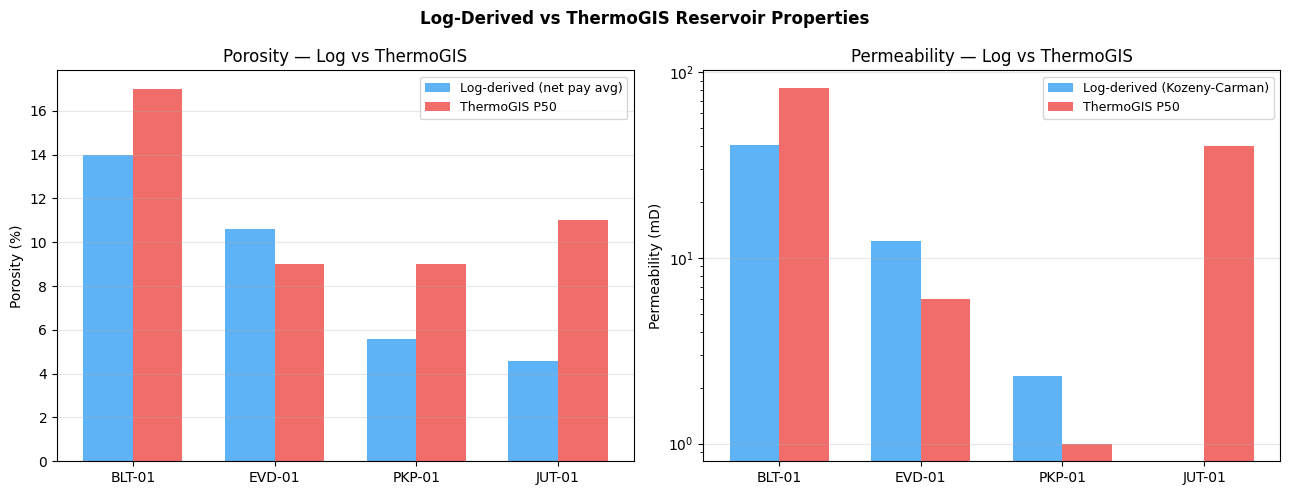

Figure saved.


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Log-Derived vs ThermoGIS Reservoir Properties', fontsize=12, fontweight='bold')

# Porosity comparison
ax    = axes[0]
valid = df_reservoir.dropna(subset=['Log_Porosity_pct', 'Thermo_Porosity_pct'])
x     = np.arange(len(valid))
w     = 0.35
ax.bar(x - w/2, valid['Log_Porosity_pct'], w, label='Log-derived (net pay avg)',
       color='#42A5F5', alpha=0.85)
ax.bar(x + w/2, valid['Thermo_Porosity_pct'], w, label='ThermoGIS P50',
       color='#EF5350', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(valid['Well'])
ax.set_ylabel('Porosity (%)')
ax.set_title('Porosity — Log vs ThermoGIS')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Permeability comparison (log scale)
ax     = axes[1]
valid2 = df_reservoir.dropna(subset=['Log_Perm_mD', 'Thermo_Perm_mD_P50'])
x2     = np.arange(len(valid2))
ax.bar(x2 - w/2, valid2['Log_Perm_mD'], w, label='Log-derived (Kozeny-Carman)',
       color='#42A5F5', alpha=0.85)
ax.bar(x2 + w/2, valid2['Thermo_Perm_mD_P50'], w, label='ThermoGIS P50',
       color='#EF5350', alpha=0.85)
ax.set_xticks(x2)
ax.set_xticklabels(valid2['Well'])
ax.set_ylabel('Permeability (mD)')
ax.set_title('Permeability — Log vs ThermoGIS')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_yscale('log')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '04_log_vs_thermo_comparison.png'), dpi=150)
plt.show()
print('Figure saved.')

## 8. Depth-Resolved Porosity and Permeability Profiles

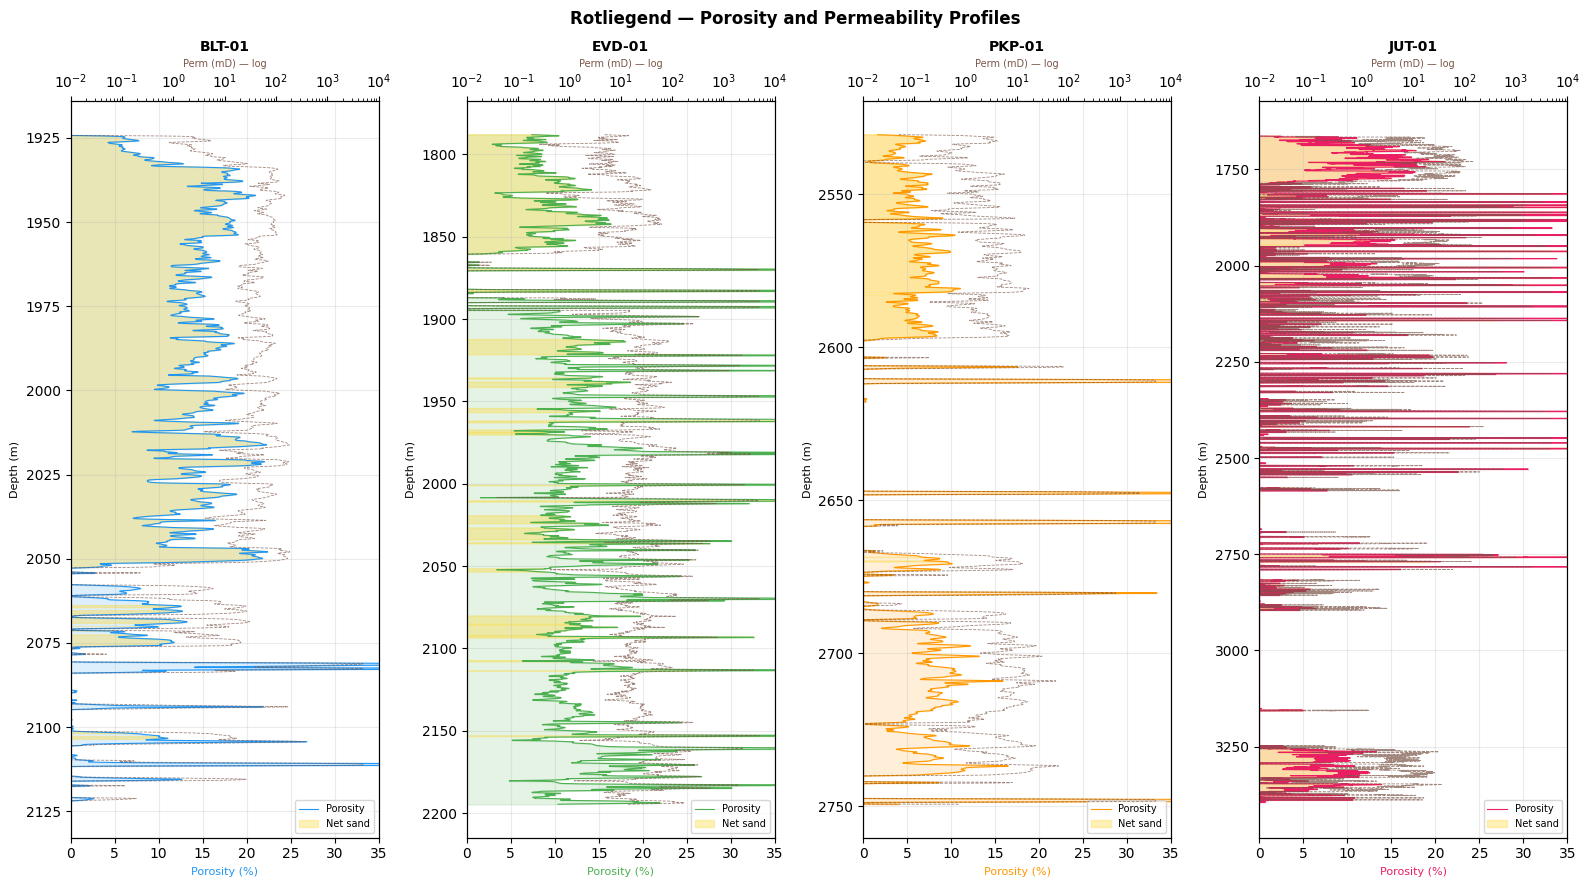

Figure saved.


In [18]:
wells_with_data = [w for w in WELLS if w in log_derived]
n_wells = len(wells_with_data)

fig, axes = plt.subplots(1, n_wells, figsize=(4 * n_wells, 9), sharey=False)
if n_wells == 1:
    axes = [axes]

fig.suptitle('Rotliegend — Porosity and Permeability Profiles', fontsize=12, fontweight='bold')

for ax, well in zip(axes, wells_with_data):
    df_w  = log_derived[well]
    ax2   = ax.twiny()
    phi_pct = df_w['phi_best'] * 100

    ax.plot(phi_pct, df_w['depth_m'], color=COLORS[well], linewidth=0.8, label='Porosity')
    ax.fill_betweenx(df_w['depth_m'], 0, phi_pct, color=COLORS[well], alpha=0.15)

    perm_valid = df_w['perm_md'].replace(0, np.nan)
    ax2.semilogx(perm_valid, df_w['depth_m'],
                 color='#795548', linewidth=0.6, linestyle='--', alpha=0.7)

    sand = df_w[df_w['is_sand']]
    if not sand.empty:
        ax.fill_betweenx(df_w['depth_m'], 0, phi_pct,
                         where=df_w['is_sand'].values,
                         color='#FDD835', alpha=0.35, label='Net sand')

    ax.set_xlabel('Porosity (%)', fontsize=8, color=COLORS[well])
    ax.set_xlim(0, 35)
    ax.set_ylabel('Depth (m)', fontsize=8)
    ax.set_title(well, fontsize=10, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(alpha=0.25)
    ax2.set_xlabel('Perm (mD) — log', fontsize=7, color='#795548')
    ax2.set_xlim(0.01, 10000)
    ax.legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '04_porosity_perm_profiles.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 9. Porosity vs Permeability Cross-Plot

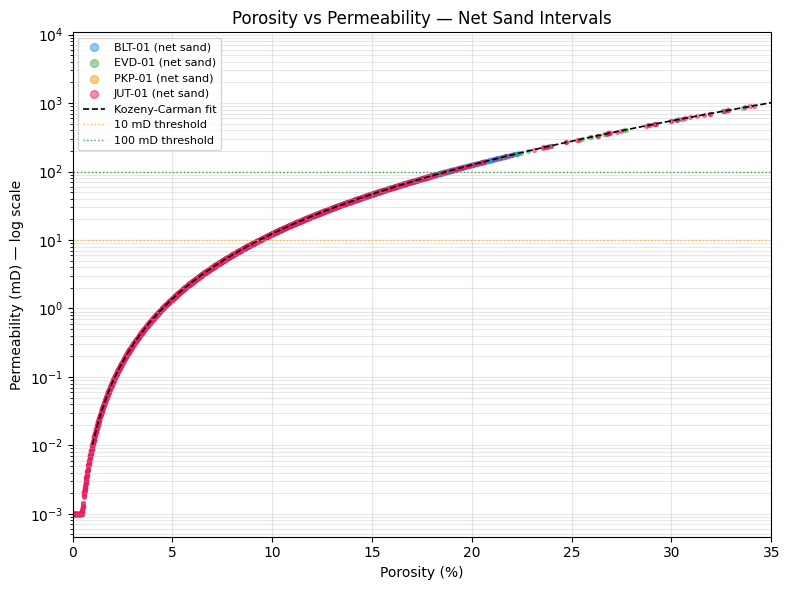

Figure saved.


In [19]:
fig, ax = plt.subplots(figsize=(8, 6))

for well, df_w in log_derived.items():
    sand = df_w[df_w['is_sand']]
    if sand.empty:
        continue
    ax.scatter(sand['phi_best'] * 100, sand['perm_md'],
               s=8, alpha=0.5, color=COLORS[well], label=f'{well} (net sand)')

phi_range = np.linspace(0.01, 0.40, 200)
k_range   = kozeny_carman_permeability(phi_range)
ax.semilogy(phi_range * 100, k_range, 'k--', linewidth=1.2, label='Kozeny-Carman fit')

ax.axhline(y=10,  color='orange', linestyle=':', linewidth=1, alpha=0.7, label='10 mD threshold')
ax.axhline(y=100, color='green',  linestyle=':', linewidth=1, alpha=0.7, label='100 mD threshold')

ax.set_xlabel('Porosity (%)')
ax.set_ylabel('Permeability (mD) — log scale')
ax.set_title('Porosity vs Permeability — Net Sand Intervals')
ax.set_yscale('log')
ax.legend(fontsize=8, markerscale=2)
ax.grid(alpha=0.3, which='both')
ax.set_xlim(0, 35)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '04_phi_perm_crossplot.png'), dpi=150)
plt.show()
print('Figure saved.')

## 10. Well Ranking

In [20]:
verdicts = {
    'BLT-01': 'PRIMARY production well',
    'JUT-01': 'SECONDARY production well',
    'PKP-01': 'Temperature reference only (low perm)',
    'EVD-01': 'Non-viable (near-zero flow at P50)',
}

print('Well Ranking — Key Reservoir Parameters:\n')
print(f'{"Well":<10} {"Net Pay":>9} {"Porosity":>10} {"Perm mD":>10} '
      f'{"Temp C":>8} {"MW P50":>8}  Verdict')
print('-' * 85)

for _, row in df_reservoir.iterrows():
    well = row['Well']
    print(f"{well:<10} "
          f"{str(row['Net_Pay_m']):>9} "
          f"{str(row['Log_Porosity_pct']):>10} "
          f"{str(row['Log_Perm_mD']):>10} "
          f"{str(row['Thermo_Temp_C_P50']):>8} "
          f"{str(row['Thermo_Power_MW_P50']):>8}  "
          f"{verdicts.get(well, '')}")

combined = df_reservoir.loc[
    df_reservoir['Well'].isin(['BLT-01', 'JUT-01']), 'Thermo_Power_MW_P50'
].sum()
print()
print(f'BLT-01 + JUT-01 combined P50 power = {combined:.1f} MW')
print(f'District heating target             = 10.0 MWth')
print(f'Gap at P50                          = {10.0 - combined:.1f} MW — bridged by heat pumps in Notebook 06')

Well Ranking — Key Reservoir Parameters:

Well         Net Pay   Porosity    Perm mD   Temp C   MW P50  Verdict
-------------------------------------------------------------------------------------
BLT-01         138.2       14.0       40.4     77.0      5.1  PRIMARY production well
EVD-01         130.5       10.6       12.3     72.0      0.0  Non-viable (near-zero flow at P50)
PKP-01          70.1        5.6        2.3     88.0      0.0  Temperature reference only (low perm)
JUT-01         840.8        4.6        0.0     72.0      2.3  SECONDARY production well

BLT-01 + JUT-01 combined P50 power = 7.4 MW
District heating target             = 10.0 MWth
Gap at P50                          = 2.6 MW — bridged by heat pumps in Notebook 06


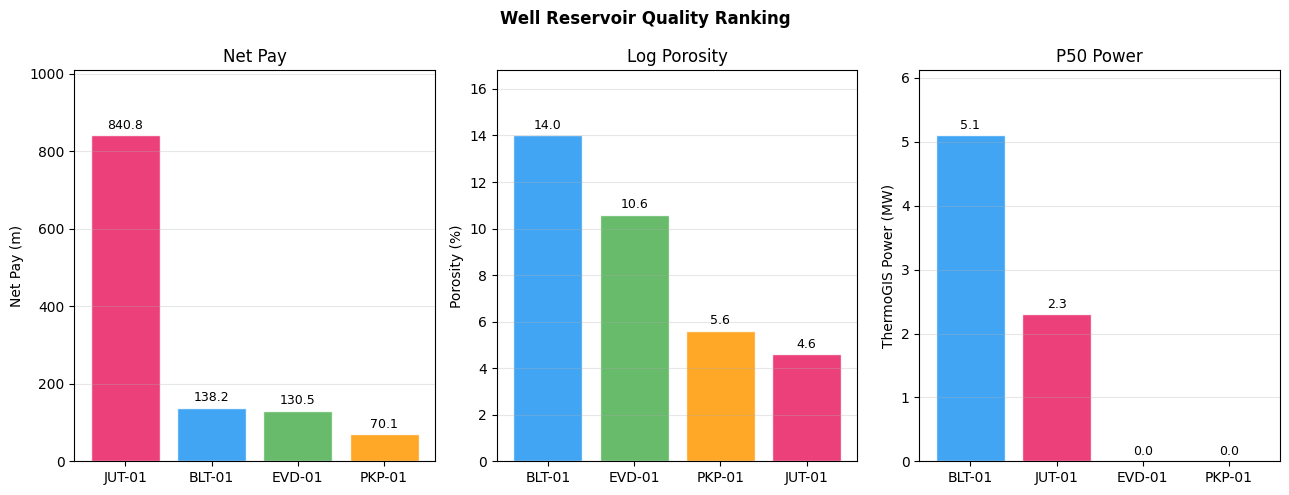

Figure saved.


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle('Well Reservoir Quality Ranking', fontsize=12, fontweight='bold')

metrics = [
    ('Net_Pay_m',            'Net Pay (m)',           'Net Pay'),
    ('Log_Porosity_pct',     'Porosity (%)',           'Log Porosity'),
    ('Thermo_Power_MW_P50',  'ThermoGIS Power (MW)',   'P50 Power'),
]

for ax, (col, ylabel, title) in zip(axes, metrics):
    valid = df_reservoir.dropna(subset=[col]).sort_values(col, ascending=False)
    bars  = ax.bar(
        valid['Well'], valid[col],
        color=[COLORS.get(w, 'gray') for w in valid['Well']],
        alpha=0.85, edgecolor='white'
    )
    for bar, val in zip(bars, valid[col]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + valid[col].max() * 0.02,
                f'{val:.1f}', ha='center', fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, valid[col].max() * 1.2)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '04_well_ranking.png'), dpi=150)
plt.show()
print('Figure saved.')

## 11. Notebook Summary

In [22]:
print('Figures generated:')
figs = [f for f in os.listdir(FIGURES_DIR) if f.startswith('04_')]
for f in sorted(figs):
    print(f'  {f}')

print()
print('Files saved:')
print('  reservoir_properties.csv   — one row per well, all key parameters')
print('  log_derived_properties.csv — depth-resolved porosity and permeability')
print()
print('Key findings:')
print('  1. BLT-01 is the highest quality reservoir — greatest net pay, porosity, and ThermoGIS power.')
print('  2. JUT-01 is a viable secondary well but weaker than BLT-01.')
print('  3. EVD-01 and PKP-01 are non-viable for production at P50.')
print('  4. Combined BLT-01 + JUT-01 P50 power falls short of the 10 MWth heating target.')
print('  5. System design in Notebook 06 must bridge the gap with heat pump uplift.')
print()
print('Next: Notebook 05 — Geothermal Potential Assessment')

Figures generated:
  04_log_vs_thermo_comparison.png
  04_phi_perm_crossplot.png
  04_porosity_perm_profiles.png
  04_well_ranking.png

Files saved:
  reservoir_properties.csv   — one row per well, all key parameters
  log_derived_properties.csv — depth-resolved porosity and permeability

Key findings:
  1. BLT-01 is the highest quality reservoir — greatest net pay, porosity, and ThermoGIS power.
  2. JUT-01 is a viable secondary well but weaker than BLT-01.
  3. EVD-01 and PKP-01 are non-viable for production at P50.
  4. Combined BLT-01 + JUT-01 P50 power falls short of the 10 MWth heating target.
  5. System design in Notebook 06 must bridge the gap with heat pump uplift.

Next: Notebook 05 — Geothermal Potential Assessment
